# lightgbm

## 1.import lobraries

In [ ]:
# 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

## 2.load data

In [ ]:

from preprocessing_22 import load_data_unscaled

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    feature_names
) = load_data_unscaled()

## 3.train model

In [4]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 195692, number of negative: 377074
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039886 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7376
[LightGBM] [Info] Number of data points in the train set: 572766, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.341661 -> initscore=-0.655899
[LightGBM] [Info] Start training from score -0.655899


,learning_rate,0.05
,n_estimators,300
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None


## 4.predictions

In [ ]:
# evaluate on validation set
y_val_pred = lgbm.predict(X_val)

print(
    "Validation Accuracy:",
    accuracy_score(y_val, y_val_pred)
)

Validation Accuracy: 0.843436318602529


In [ ]:
# evaluate on test set
y_pred = lgbm.predict(X_test)

y_prob = lgbm.predict_proba(X_test)[:,1]

## 5.matrics

In [ ]:
# evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

Accuracy : 0.8408
Precision: 0.7897
Recall   : 0.7280
F1 Score : 0.7576
ROC AUC  : 0.9087


In [ ]:
# classification matrix
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.90      0.88     80802
           1       0.79      0.73      0.76     41934

    accuracy                           0.84    122736
   macro avg       0.83      0.81      0.82    122736
weighted avg       0.84      0.84      0.84    122736



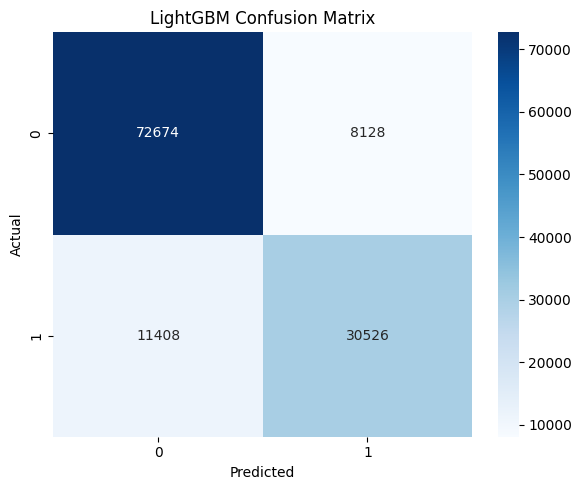

In [ ]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("LightGBM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../results/plots/lgbm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6.roc curve

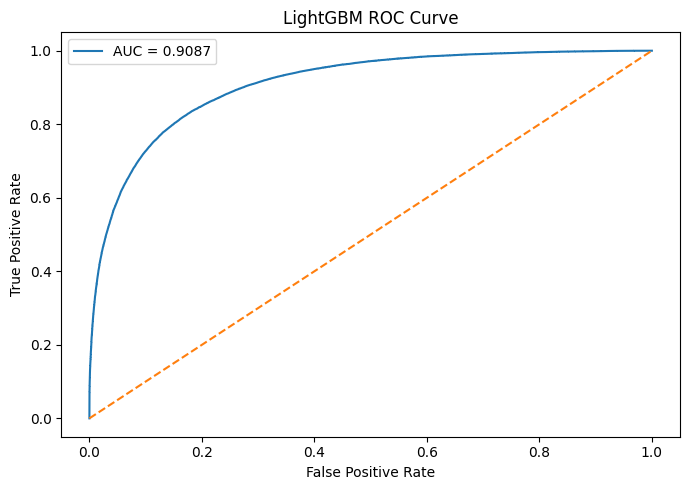

In [10]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("LightGBM ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/plots/lgbm_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
joblib.dump(
    lgbm,
    "../models/higgs_lightgbm.pkl"
)

['../models/higgs_lightgbm.pkl']